In [21]:
from cobra import Model, Reaction, Metabolite
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cobra.io import load_json_model
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [22]:
model = load_json_model('iML1515.json')
model.optimize()

,fluxes,reduced_costs
CYTDK2,0.000000e+00,7.799850e-17
XPPT,0.000000e+00,7.047314e-18
HXPRT,0.000000e+00,-1.504671e-02
NDPK5,1.001644e-15,-0.000000e+00
SHK3Dr,3.342403e-01,-1.131461e-16
...,...,...
MPTS,0.000000e+00,-3.642919e-17
MOCOS,0.000000e+00,-5.642514e-03
BMOGDS2,0.000000e+00,-3.338488e-01
FESD2s,0.000000e+00,9.540979e-18


In [23]:
model.reactions.get_by_id('EX_glc__D_e').lower_bound = -10

In [24]:
nitrogen_exchange_map = {'NH4Cl': 'EX_nh4_e','Adenine':'EX_ade_e','L-Cys':'EX_cys__L_e','Cytosine':'EX_csn_e',
                        'Cytidine':'EX_cytd_e','Putrescine':'EX_ptrc_e','L-Pro':'EX_pro__L_e','Adenosine':'EX_adn_e',
                        'L-Asn':'EX_asn__L_e','GlcNAc':'EX_acgam_e','Glycine':'EX_gly_e','L-Orn':'EX_orn_e',
                        'L-Asp':'EX_asp__L_e','D-Ala':'EX_ala__D_e','L-Ala':'EX_ala__L_e','L-Arg':'EX_arg__L_e',
                        'GABA':'EX_4abut_e','L-Ser':'EX_ser__L_e','Guanosine':'EX_gsn_e'}

In [25]:
from cobra.flux_analysis import pfba

def production(model, fluxes, met_id):
    """Total production rate of a metabolite (mmol/gDW/h)."""
    met = model.metabolites.get_by_id(met_id)
    rate = 0
    for rxn in met.reactions:
        flux = rxn.metabolites[met] * fluxes[rxn.id]
        if flux > 0:
            rate += flux
    return rate


def analyze(model, ex_id, n_supply=10,c_total=60):
    """pFBA with `ex_id` as the sole N source, dosed at n_supply mmol N/gDW/h.

    Returns (summary dict, full pFBA flux vector).
    """
    met = next(iter(model.reactions.get_by_id(ex_id).metabolites))
    n_per_mol = met.elements['N']         # e.g. 5 for adenine, 1 for glycine
    c_per_mol = met.elements.get('C', 0)
    uptake = n_supply / n_per_mol         # same nitrogen for every source
    glucose = max(0, (c_total - c_per_mol * uptake) / 6)   # glucose tops up the C budget

    with model:
        medium = model.medium
        medium.pop('EX_nh4_e', None)
        medium[ex_id] = uptake
        medium['EX_glc__D_e'] = glucose
        model.medium = medium
        sol = pfba(model)

    v = sol.fluxes
    summary = {
        'N_per_mol': n_per_mol,
        'growth': v['BIOMASS_Ec_iML1515_core_75p37M'],
        'ATP':    production(model, v, 'atp_c'),
        'NADH':   production(model, v, 'nadh_c'),
        'NADPH':  production(model, v, 'nadph_c'),
        'QH2':    production(model, v, 'q8h2_c'),
        'O2':     -v['EX_o2_e'],
        'uptake': -v[ex_id],
    }
    return summary, v


results = {name: analyze(model, ex) for name, ex in nitrogen_exchange_map.items()}

df = pd.DataFrame({name: summary for name, (summary, _) in results.items()}).T

# Flux distributions: reactions (rows) x N sources (columns), mmol/gDW/h
fluxes = pd.DataFrame({name: v for name, (_, v) in results.items()})

df['N_uptake'] = df['uptake'] * df['N_per_mol']    # mmol N/gDW/h actually consumed

for col in ['growth', 'ATP', 'NADH', 'NADPH', 'QH2', 'O2']:
    df[col + '_per_N'] = df[col] / df['N_uptake']

df.sort_values('growth_per_N', ascending=False).round(3)

,N_per_mol,growth,ATP,NADH,NADPH,QH2,O2,uptake,N_uptake,growth_per_N,ATP_per_N,NADH_per_N,NADPH_per_N,QH2_per_N,O2_per_N
GlcNAc,1.0,0.926,99.372,43.582,13.188,46.444,23.226,10.000,10.000,0.093,9.937,4.358,1.319,4.644,2.323
Putrescine,2.0,0.926,94.575,45.559,8.578,52.049,26.028,5.000,10.000,0.093,9.457,4.556,0.858,5.205,2.603
NH4Cl,1.0,0.877,93.048,42.101,12.490,44.258,22.132,9.471,9.471,0.093,9.824,4.445,1.319,4.673,2.337
L-Orn,2.0,0.878,90.003,42.681,7.716,49.192,24.600,5.000,10.000,0.088,9.000,4.268,0.772,4.919,2.460
GABA,1.0,0.875,90.232,42.891,7.782,54.455,27.231,10.000,10.000,0.087,9.023,4.289,0.778,5.446,2.723
L-Pro,1.0,0.870,89.545,36.775,6.465,54.904,27.455,10.000,10.000,0.087,8.954,3.678,0.646,5.490,2.746
L-Arg,4.0,0.855,87.118,40.353,6.671,43.659,21.833,2.500,10.000,0.085,8.712,4.035,0.667,4.366,2.183
L-Ala,1.0,0.842,87.133,41.804,7.483,47.265,23.635,10.000,10.000,0.084,8.713,4.180,0.748,4.726,2.364
D-Ala,1.0,0.842,87.133,41.804,7.483,47.263,23.635,10.000,10.000,0.084,8.713,4.180,0.748,4.726,2.364
Adenosine,5.0,0.817,79.939,37.266,10.616,37.801,19.719,2.000,10.000,0.082,7.994,3.727,1.062,3.780,1.972


In [26]:
group_A_subs = ['NH4Cl','Adenine','L-Cys']
group_B_subs = ['Cytososine, Cytidine']
group_C_subs = ['Putrescine','L-Pro','Adenosine','L-Asn','GlcNAc','Glycine','L-Orn','L-Asp','D-Ala','L-Ala','L-Arg']
group_D_subs = ['GABA','L-Ser','Guanosine']

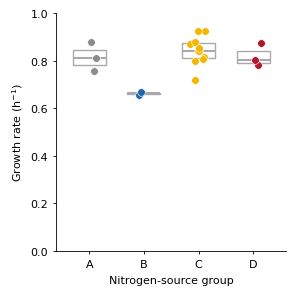

In [27]:
import numpy as np
import matplotlib.pyplot as plt

group_map = {s: g for g, subs in {
    'A': ['NH4Cl', 'Adenine', 'L-Cys'],
    'B': ['Cytosine', 'Cytidine'],
    'C': ['Putrescine', 'L-Pro', 'Adenosine', 'L-Asn', 'GlcNAc', 'Glycine',
          'L-Orn', 'L-Asp', 'D-Ala', 'L-Ala', 'L-Arg'],
    'D': ['GABA', 'L-Ser', 'Guanosine'],
}.items() for s in subs}

df = df.copy()
df['group'] = df.index.map(group_map)

ORDER  = ['A', 'B', 'C', 'D']
COLORS = {'A': '#8C8C8C', 'B': '#2166AC', 'C': '#F2B701', 'D': '#B2182B'}

# Journal-style text and line weights, scoped to this figure only
RC = {'font.family': 'sans-serif', 'font.size': 8, 'axes.linewidth': 0.6,
      'xtick.major.width': 0.6, 'ytick.major.width': 0.6,
      'xtick.major.size': 2.5, 'ytick.major.size': 2.5,
      'pdf.fonttype': 42, 'ps.fonttype': 42}          # editable text in Illustrator

rng = np.random.default_rng(7)

with plt.rc_context(RC):
    fig, ax = plt.subplots(figsize=(3, 3))        # ~85 mm single column

    for x, g in enumerate(ORDER):
        vals = df.loc[df['group'].eq(g), 'growth'].dropna()
        q1, med, q3 = vals.quantile([0.25, 0.5, 0.75])
        # Box spans the interquartile range; line marks the median
        ax.bar(x, q3 - q1, bottom=q1, width=0.6, facecolor='none',
               edgecolor='darkgrey', linewidth=1)
        ax.hlines(med, x - 0.3, x + 0.3, color='darkgrey', linewidth=1.5, zorder=3)
        ax.scatter(x + rng.uniform(-0.15, 0.15, len(vals)), vals, s=30,
                   color=COLORS[g], edgecolor='white', linewidth=0.4, zorder=4)

    ax.set_xticks(range(len(ORDER)), ORDER)
    ax.set_xlim(-0.6, len(ORDER) - 0.4)
    ax.set_ylim(0,1)
    ax.set_xlabel('Nitrogen-source group')
    ax.set_ylabel('Growth rate (h$^{-1}$)')
    ax.spines[['top', 'right']].set_visible(False)

    fig.tight_layout()
    fig.savefig('figs/supp/growth_rate.pdf', bbox_inches='tight')
    fig.savefig('figs/supp/growth_rate.png', dpi=600, bbox_inches='tight')
    plt.show()

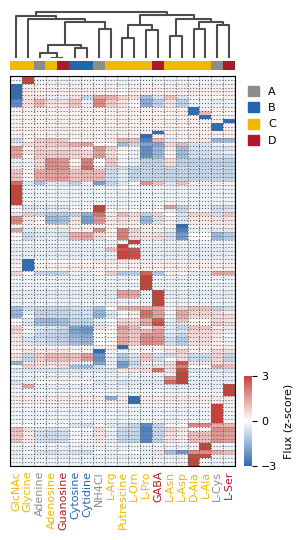

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib.patches import Patch
from scipy.cluster.hierarchy import linkage, dendrogram

# The 100 reactions whose flux varies most across N sources
active = fluxes.loc[fluxes.std(axis=1).nlargest(100).index]
z = active.sub(active.mean(axis=1), axis=0).div(active.std(axis=1), axis=0)   # row z-score

row_order = dendrogram(linkage(z.values, 'average', metric='correlation'), no_plot=True)['leaves']
col_link  = linkage(z.T.values, 'average', metric='correlation')

group_colors = {'A': '#8C8C8C', 'B': '#2166AC', 'C': '#F2B701', 'D': '#B2182B'}
template_cmap = LinearSegmentedColormap.from_list('template', ['#2F6DB5', '#FFFFFF', '#C8423A'])

with plt.rc_context({'font.family': 'sans-serif', 'font.size': 8,
                     'pdf.fonttype': 42, 'ps.fonttype': 42}):
    fig = plt.figure(figsize=(3, 6))
    ax_dend = fig.add_axes([0.10, 0.86, 0.75, 0.08])
    ax_grp  = fig.add_axes([0.10, 0.84, 0.75, 0.015])
    ax_heat = fig.add_axes([0.10, 0.18, 0.75, 0.65])
    ax_cbar = fig.add_axes([0.88, 0.18, 0.025, 0.15])

    col_order = dendrogram(col_link, ax=ax_dend, color_threshold=0,
                           above_threshold_color='0.3')['leaves']
    ax_dend.axis('off')

    cols   = z.columns[col_order]
    groups = cols.map(group_map)

    ax_grp.imshow([list(range(len(cols)))], aspect='auto',
                  cmap=ListedColormap([group_colors[g] for g in groups]))
    ax_grp.axis('off')

    im = ax_heat.imshow(z.iloc[row_order][cols].values, aspect='auto',
                        cmap=template_cmap, vmin=-3, vmax=3, interpolation='nearest')
    ax_heat.set_xticks(range(len(cols)))
    ax_heat.set_xticklabels(cols, rotation=90)
    ax_heat.set_yticks([])
    ax_heat.tick_params(length=0)
    # Dotted cell borders
    ax_heat.set_xticks(np.arange(-0.5, len(cols)), minor=True)
    ax_heat.set_yticks(np.arange(-0.5, len(z)), minor=True)
    ax_heat.grid(which='minor', color='0.4', linestyle=':', linewidth=0.8)
    ax_heat.tick_params(which='minor', length=0)
    for lbl, g in zip(ax_heat.get_xticklabels(), groups):   # tick labels in group colour
        lbl.set_color(group_colors[g])

    cb = fig.colorbar(im, cax=ax_cbar, ticks=[-3, 0, 3])
    cb.set_label('Flux (z-score)')
    cb.outline.set_visible(False)

    fig.legend(handles=[Patch(color=c, label=k) for k, c in group_colors.items()],
               loc='upper left', bbox_to_anchor=(0.86, 0.83), frameon=False,
               handlelength=1, handleheight=1)

    fig.savefig('figs/supp/flux_clustermap.pdf', bbox_inches='tight')
    fig.savefig('figs/supp/flux_clustermap.png', dpi=600, bbox_inches='tight')
    plt.show()

In [29]:
biomass = model.reactions.get_by_id('BIOMASS_Ec_iML1515_core_75p37M')
n_mets  = [m.id for m, c in biomass.metabolites.items() if c < 0 and m.elements.get('N', 0)]

# Total production rate (mmol/gDW/h) of each N-containing biomass precursor, per N source
n_production = pd.DataFrame({src: {m: production(model, fluxes[src], m) for m in n_mets}
                             for src in fluxes.columns})


In [30]:
n_production

,NH4Cl,Adenine,L-Cys,Cytosine,Cytidine,Putrescine,L-Pro,Adenosine,L-Asn,GlcNAc,Glycine,L-Orn,L-Asp,D-Ala,L-Ala,L-Arg,GABA,L-Ser,Guanosine
10fthf_c,0.866753,0.349209,0.745623,0.648764,0.660999,0.917389,0.859344,0.352516,0.796638,0.915117,0.791444,0.867485,0.710089,0.832341,0.832341,0.844981,0.864479,0.772595,0.346809
ala__L_c,0.511431,0.472013,0.439957,0.382805,0.390025,0.539968,0.507059,0.476484,0.470059,0.539968,0.465838,0.511863,0.418991,8.125095,10.001109,0.498584,0.510089,0.454743,0.468770
amet_c,0.000788,0.000727,0.000677,0.000589,0.000601,0.000831,0.000781,0.000734,0.000724,0.000831,0.000717,0.000788,0.000645,0.000756,0.000756,0.000768,0.000785,0.000700,0.000722
arg__L_c,0.259409,0.239415,0.223156,0.194167,0.197829,0.273884,0.257191,0.241683,0.238424,0.273884,0.236283,0.259628,0.212521,0.249110,0.249110,2.500000,0.258728,0.230656,0.237770
asn__L_c,0.211405,0.195111,0.181860,0.158236,0.161220,0.223201,0.209598,0.196959,0.194303,0.223201,0.192558,0.211583,0.173194,0.203011,0.203011,0.206094,0.210850,0.187972,0.193770
asp__L_c,2.567693,1.765088,2.208853,1.704772,1.736921,2.710969,2.545745,1.781808,4.805697,2.710969,2.338791,2.569862,10.000000,2.465751,2.465751,2.250303,2.560956,2.283089,1.993553
atp_c,93.047603,81.216075,89.530898,70.737099,68.393676,94.574935,89.544786,79.939349,83.300826,99.371840,83.990046,90.002864,75.342524,87.132766,87.132766,87.118210,90.232187,82.086260,78.540965
btn_c,0.000002,0.000002,0.000002,0.000001,0.000001,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000001,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002
coa_c,16.266601,13.549347,20.747476,13.524555,13.062983,11.545877,14.692952,13.279851,16.296381,18.343384,15.642863,11.151453,15.176118,18.716761,18.716761,15.513127,11.228325,20.291503,13.582829
ctp_c,0.299519,0.276434,0.257661,0.224190,0.245918,0.291216,0.296959,0.279053,0.275290,0.316232,0.272818,0.276058,0.225970,0.287628,0.264875,0.291996,0.275102,0.266320,0.274535


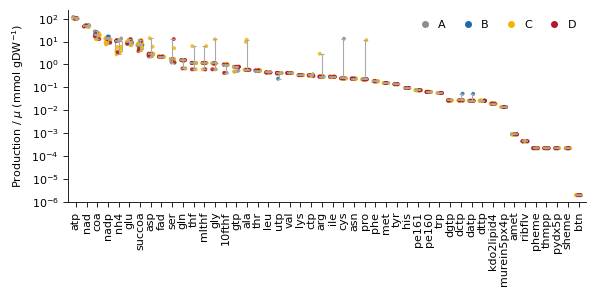

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Production per unit growth: (mmol gDW^-1 h^-1) / h^-1 = mmol gDW^-1
per_growth = n_production / fluxes.loc[biomass.id]
per_growth = per_growth[per_growth.gt(0).all(axis=1)]          # log axis needs positive values
per_growth = per_growth.loc[per_growth.median(axis=1).sort_values(ascending=False).index]

labels = [m.rsplit('_', 1)[0].replace('__L', '') for m in per_growth.index]   # arg__L_c -> arg
group_colors = {'A': '#8C8C8C', 'B': '#2166AC', 'C': '#F2B701', 'D': '#B2182B'}
rng = np.random.default_rng(7)

with plt.rc_context({'font.family': 'sans-serif', 'font.size': 8, 'axes.linewidth': 0.6,
                     'xtick.major.width': 0.6, 'ytick.major.width': 0.6,
                     'pdf.fonttype': 42, 'ps.fonttype': 42}):
    fig, ax = plt.subplots(figsize=(6.0, 3))

    # Box = interquartile range, line = median, error bar = min to max across N sources
    q1, med, q3 = (per_growth.quantile(q, axis=1) for q in (0.25, 0.5, 0.75))
    xs = np.arange(len(per_growth))
    ax.bar(xs, q3 - q1, bottom=q1, width=0.6, facecolor='none',
           edgecolor='darkgrey', linewidth=0.8)
    ax.hlines(med, xs - 0.3, xs + 0.3, color='darkgrey', linewidth=1.2, zorder=3)
    ax.errorbar(xs, med, yerr=[med - per_growth.min(axis=1), per_growth.max(axis=1) - med],
                fmt='none', ecolor='darkgrey', elinewidth=0.8, capsize=1.5, capthick=0.8, zorder=2)

    for src in per_growth.columns:
        x = np.arange(len(per_growth)) + rng.uniform(-0.25, 0.25, len(per_growth))
        ax.scatter(x, per_growth[src], s=8, color=group_colors[group_map[src]],
                   edgecolor='none', alpha=0.85)

    ax.set_yscale('log')
    ax.set_ylim(per_growth.min().min() / 2, per_growth.max().max() * 2)   # bars break log autoscaling
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90)
    ax.set_xlim(-0.7, len(labels) - 0.3)
    ax.set_ylabel('Production / $\\mu$ (mmol gDW$^{-1}$)')
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(handles=[Line2D([], [], marker='o', ls='none', color=c, label=k, markersize=4)
                       for k, c in group_colors.items()],
              frameon=False, ncol=4, loc='upper right', handletextpad=0.2, columnspacing=1)
    ax.minorticks_off()

    fig.tight_layout()
    fig.savefig('figs/supp/n_production.pdf', bbox_inches='tight')
    fig.savefig('figs/supp/n_production.png', dpi=600, bbox_inches='tight')
    plt.show()

In [32]:
coef = pd.Series({m: -biomass.get_coefficient(m) for m in n_mets})
coef['atp_c'] -= biomass.get_coefficient('adp_c')        # net ATP: drop the GAM ATP that is recycled to ADP
weights = coef / coef.sum()

n_total = n_production.mul(weights, axis=0).sum()         # one weighted production rate per N source

n_total

NH4Cl         3.501531
Adenine       2.913569
L-Cys         3.402195
Cytosine      2.633533
Cytidine      2.569525
Putrescine    3.663393
L-Pro         3.822712
Adenosine     2.883975
L-Asn         3.140254
GlcNAc        3.720646
Glycine       4.088758
L-Orn         3.483317
L-Asp         3.048069
D-Ala         3.914113
L-Ala         4.066126
L-Arg         3.367634
GABA          3.510810
L-Ser         3.336593
Guanosine     2.862172
dtype: float64

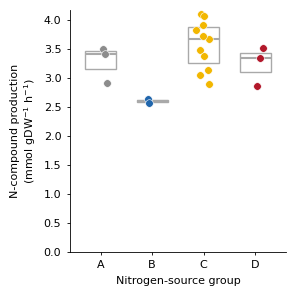

In [33]:
groups = n_total.index.map(group_map)
rng = np.random.default_rng(7)

with plt.rc_context(RC):
    fig, ax = plt.subplots(figsize=(3, 3))        # ~85 mm single column

    for x, g in enumerate(ORDER):
        vals = n_total[groups == g]
        q1, med, q3 = vals.quantile([0.25, 0.5, 0.75])
        # Box spans the interquartile range; line marks the median
        ax.bar(x, q3 - q1, bottom=q1, width=0.6, facecolor='none',
               edgecolor='darkgrey', linewidth=1)
        ax.hlines(med, x - 0.3, x + 0.3, color='darkgrey', linewidth=1.5, zorder=3)
        ax.scatter(x + rng.uniform(-0.15, 0.15, len(vals)), vals, s=30,
                   color=COLORS[g], edgecolor='white', linewidth=0.4, zorder=4)

    ax.set_xticks(range(len(ORDER)), ORDER)
    ax.set_xlim(-0.6, len(ORDER) - 0.4)
    ax.set_ylim(0, None)
    ax.set_xlabel('Nitrogen-source group')
    ax.set_ylabel('N-compound production\n(mmol gDW$^{-1}$ h$^{-1}$)')
    ax.spines[['top', 'right']].set_visible(False)

    fig.tight_layout()
    fig.savefig('figs/supp/n_total.pdf', bbox_inches='tight')
    fig.savefig('figs/supp/n_total.png', dpi=600, bbox_inches='tight')
    plt.show()